<a href="https://colab.research.google.com/github/amscally-dsci/Data-Science-Cohort-20/blob/main/Project-6/Project_6_Images_To_Do_List.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Images – To Do List



Prior to starting this problem, be sure to enable the GPU runtime processing in your Jupyter notebook.



## Problem Definition


Use deep learning to classify images using binary classification. Our training set is images of cats and dogs.


* Write a concise problem definition for the project. Put it in a text field at the top of your Jupyter notebook.

* Load necessary packages.



### Imports

In [1]:
import tensorflow.keras as keras
import tensorflow as tf
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
from sklearn import datasets
from keras.models import Sequential
from keras.layers import Dense, Input, Flatten, Conv2D, MaxPooling2D
from keras.utils import plot_model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


## Data Collection



* Load pickled data from X.pickle and y.pickle from the AWS S3 bucket.



In [2]:
# Feature set (the images of dogs and cats)
images_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle"
images_url


'https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle'

In [3]:
image_array = pd.read_pickle( images_url )
type(image_array)


numpy.ndarray

In [4]:
image_array.shape

(24946, 100, 100, 1)

In [5]:
# Target binary data set 0 is dog and 1 is cat
target_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle"
target_url


'https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle'

In [6]:
target = pd.read_pickle( target_url )
type(target)


list

In [7]:
y=np.array(target)

In [8]:
type(y)

numpy.ndarray

In [9]:
y

array([0, 1, 1, ..., 1, 0, 1])

In [10]:
y.size

24946

## Data Cleaning



* Scale the values in X so that they fall between 0 and 1 by dividing by 255.



In [11]:
X=image_array/255
X

array([[[[0.37254902],
         [0.36862745],
         [0.38431373],
         ...,
         [0.66666667],
         [0.6745098 ],
         [0.67058824]],

        [[0.36078431],
         [0.35686275],
         [0.37254902],
         ...,
         [0.66666667],
         [0.6745098 ],
         [0.67058824]],

        [[0.34901961],
         [0.35686275],
         [0.36078431],
         ...,
         [0.64705882],
         [0.6627451 ],
         [0.6627451 ]],

        ...,

        [[0.32941176],
         [0.29803922],
         [0.28627451],
         ...,
         [0.52941176],
         [0.64313725],
         [0.60392157]],

        [[0.32156863],
         [0.30980392],
         [0.27843137],
         ...,
         [0.55686275],
         [0.5254902 ],
         [0.6       ]],

        [[0.31372549],
         [0.33333333],
         [0.33333333],
         ...,
         [0.59215686],
         [0.57254902],
         [0.54117647]]],


       [[[0.67058824],
         [0.60392157],
         [0.54

## Exploratory Data Analysis



* Look at the shape of X and y. Ensure that X is 4 dimensional.

* Plot a few ( >5 ) of the images in X using `plt.imshow()`.

* Look at the response values in y for those images.

* Hint: you may want to start with a random subset to get familiar with the process of building a NN.  Then go through the process again with the full set.



In [12]:
X.shape,y.shape

((24946, 100, 100, 1), (24946,))

In [13]:
X.ndim

4

In [14]:
X[42]

array([[[0.87058824],
        [0.9254902 ],
        [0.99215686],
        ...,
        [0.72156863],
        [0.72156863],
        [0.74117647]],

       [[0.87843137],
        [0.98431373],
        [0.97647059],
        ...,
        [0.70980392],
        [0.74901961],
        [0.74509804]],

       [[0.89803922],
        [0.99215686],
        [0.98823529],
        ...,
        [0.72941176],
        [0.71764706],
        [0.72156863]],

       ...,

       [[0.84313725],
        [0.85882353],
        [0.83529412],
        ...,
        [0.63529412],
        [0.62352941],
        [0.60784314]],

       [[0.88235294],
        [0.86666667],
        [0.88627451],
        ...,
        [0.65882353],
        [0.65098039],
        [0.63921569]],

       [[0.88235294],
        [0.90196078],
        [0.94901961],
        ...,
        [0.66666667],
        [0.67843137],
        [0.66666667]]])

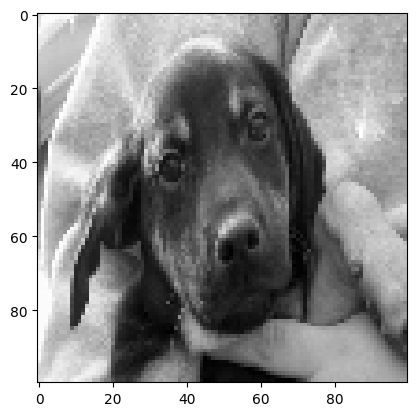

In [16]:
plt.imshow(X[42],cmap='grey')

In [17]:
# 0 is dog
y[42]

np.int64(0)

In [38]:
random_images = np.random.choice(X.shape[0], size=10, replace=False)

label = 1


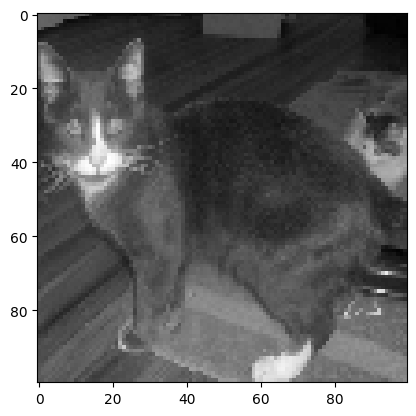

label = 1


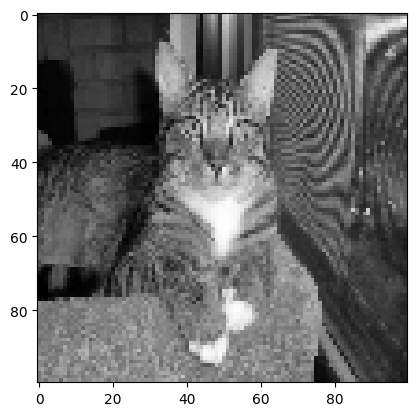

label = 0


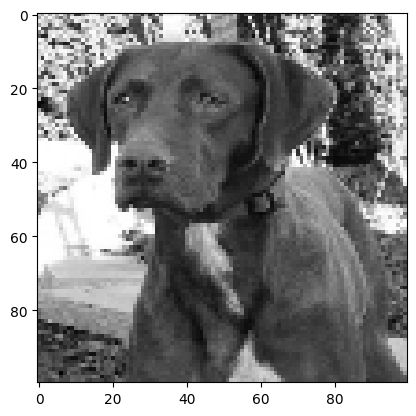

label = 0


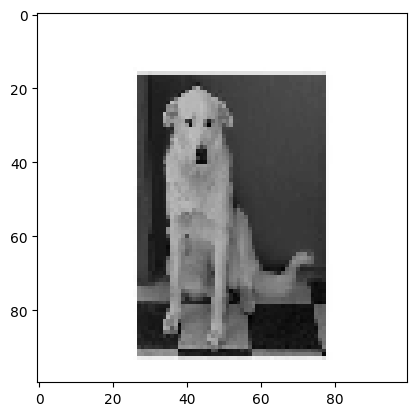

label = 1


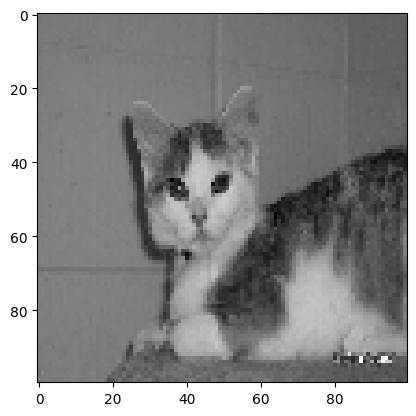

label = 0


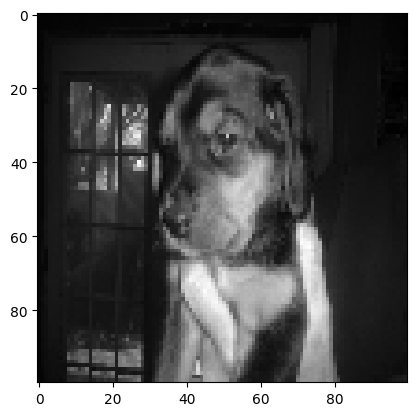

label = 0


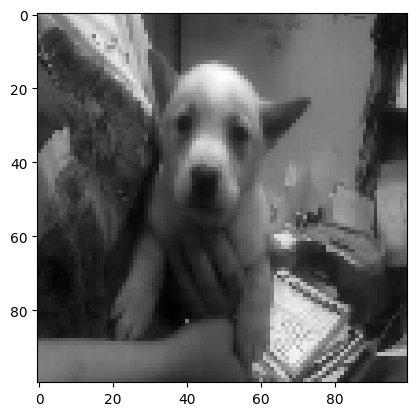

label = 0


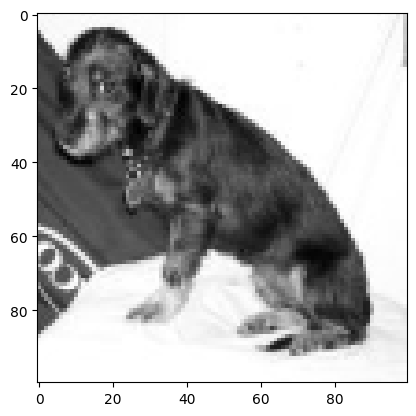

label = 0


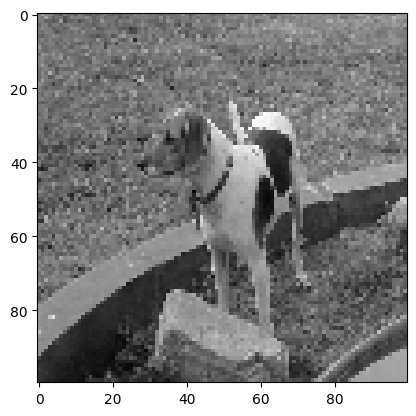

label = 1


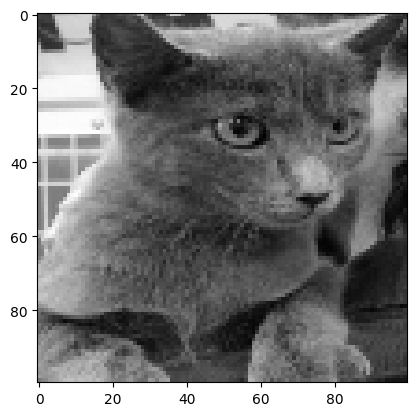

In [39]:
for image in random_images:
  print(f'label = {y[image]}')
  plt.imshow(X[image],cmap='grey')
  plt.show()

In [43]:
random_index = np.random.choice(X.shape[0], size=100, replace=False)
random_index

array([12486, 20923,  4219, 10271, 19345,  4164, 22477,  5317,  2601,
       15449, 16384, 20002,  8934,  3597,   703, 12398,  3716,  2560,
       12333, 23149, 24046,  3135, 20146,  8935,  6632,  1804,  7291,
        2841, 17065,  6159,   838, 23513,   679, 18439,  9405, 13218,
       10044, 21050, 14201, 10341, 21218,  1083, 16404, 17456, 18686,
       11907,  9031, 22187,  4896, 14929, 20877,  8607, 14327, 13117,
        9124, 20164, 10059, 10107, 14079, 20542, 15469,  8612, 10095,
        4590,  6857, 16305, 11826,  6421,  9344, 24547,  9271,  3593,
       20112,  8768,  2333,  1098,  3391, 11507,   391, 17525, 10920,
       13297, 18243, 16092,   744, 11273, 17970, 22236,  3548, 11714,
        6703, 16997,  6080, 21653, 12461, 23526,  1735,  9152,  4013,
        5333])

In [44]:
random_images = X[random_index]

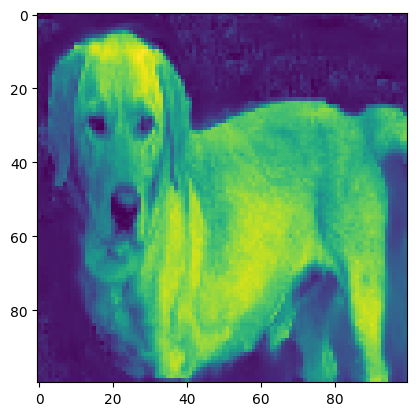

In [45]:
plt.imshow(random_images[0])

In [46]:
# Associated targets for the random images
random_targets=y[random_index]
random_targets

array([0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0,
       1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0])

## Data Processing



* Split X and y into training and testing sets.

*  Build a convolutional neural network with the following:
  * Sequential layers
  * At least two 2D convolutional layers using the 'relu' activation function and a (3,3) kernel size.
  * A MaxPooling2D layer after each 2D convolutional layer that has a pool size of (2,2).
  * A dense output layer using the 'sigmoid' activation function.
  Note: you can play around with the number of layers and nodes to try to get better performance.

* Compile your model. Use the 'adam' optimizer. Determine which loss function and metric is most appropriate for this problem.

* Fit your model using the training set.

* Evaluate your model using the testing set.

* Plot the distribution of probabilities for the testing set.

* Define a function that will read in a new image and convert it to a 4 dimensional array of pixels (ask the instructor for help with this). Hint: [numpy.reshape]( https://numpy.org/doc/stable/reference/generated/numpy.reshape.html )

* Use the function defined above to read in the dog.jpg image that is saved in the AWS S3 bucket.

* Use the neural network you created to predict whether the image is a dog or a cat.



In [49]:
# Split X and y into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(
  random_images,
  random_targets,
  test_size=0.2,
  random_state=42,
)

In [50]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((80, 100, 100, 1), (20, 100, 100, 1), (80,), (20,))

In [51]:
# Build a convolutional neural network with the following:


In [58]:
model = Sequential()


In [71]:
# X_test.shape[1:]


(100, 100, 1)

In [59]:
# Define input layer
model.add(
  Input(
    shape=X_train.shape[1:],
    name="model_input",
  ),
)


In [60]:
# Define first hidden layer
model.add(
  Conv2D(
    name = "Conv1",
    filters = 64,
    kernel_size = (3,3),
    activation = 'relu',
  )
)

model.add(
    MaxPooling2D(pool_size=(2,2))
)


In [61]:
# Define second hidden layer
model.add(
  Conv2D(
    name = "Conv2",
    filters = 64,
    kernel_size = (3,3),
    activation = 'relu',
  )
)

model.add(
  MaxPooling2D(pool_size=(2,2))
)


In [62]:
# Flatten data to be used in output layer
model.add(
    Flatten()
)

# Define output layer
model.add(
  Dense(
    name = "output",
    units = 1,
    activation = 'sigmoid',
  )
)


#### Compile model

In [63]:
# Compile model
model.compile(
  optimizer = 'adam',
  loss = 'binary_crossentropy',
  metrics = ['accuracy'],
)


#### Fit model

In [64]:
# Fit model
model.fit(X_train, y_train, epochs=2)

Epoch 1/2
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 576ms/step - accuracy: 0.5000 - loss: 0.7678
Epoch 2/2
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 928ms/step - accuracy: 0.4500 - loss: 0.6769


In [65]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Conv1 (Conv2D)                  │ (None, 98, 98, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 49, 49, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2 (Conv2D)                  │ (None, 47, 47, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 33856)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │        33,857 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 214,277 (837.02 KB)

 Trainable params: 71,425 (279.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 142,852 (558.02 KB)

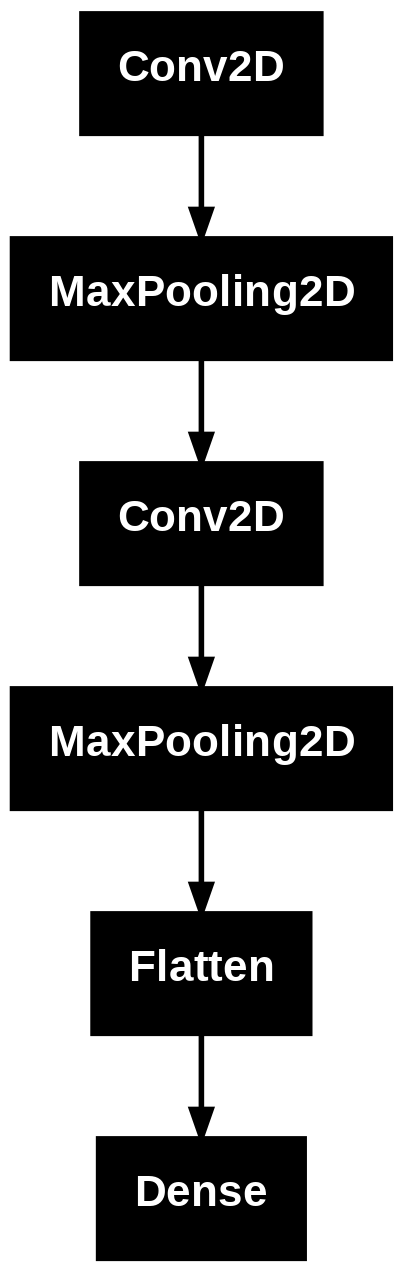

In [66]:
plot_model(model)

#### Evaluate model

In [67]:
# Change test set to 4-D
X_test2 = X_test.reshape( X_test.shape + (1,) )

# Evaluate model
val_loss, val_acc = model.evaluate(X_test2, y_test)
print(val_loss)
print(val_acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step - accuracy: 0.6000 - loss: 0.6687
0.6687433123588562
0.6000000238418579


In [68]:
X_test2.shape

(20, 100, 100, 1, 1)

## Communication of Results



* Communicate the results of your analysis.



## **BONUS** (optional)



* Upload an image of your (or your friend's or family's) dog or cat and use your model to predict whether the image is a dog or cat.
* Hint: you'll probably need to convert the image from color to grayscale.  OpenCV, pillow, and other libraries are your friend.